# Gelişmiş Model 2: Voting Regressor (Hibrit Yaklaşım)
### Amaç: Farklı Algoritmaların Güçlerini Birleştirmek
Bu çalışmada, tek bir modelin zayıf yönlerini kapatmak için **Voting Regressor** (Oylama Regresyonu) kullanılmıştır.

**Kullanılan Alt Modeller (Vize Modelleri + Gelişmiş Ağaç):**
1.  **Ridge Regresyon:** Doğrusal ilişkiler için (Vize Dönemi Modeli).
2.  **SVR (Destek Vektör Regresyonu):** Karmaşık yapılar için (Vize Dönemi Modeli).
3.  **Extra Trees Regressor:** Varyansı düşük, güçlü bir ağaç modeli (Yeni Eklenen).

Bu çalışmada, güçlü modelin (ExtraTrees) ağırlığı artırılarak hibrit yapının performansı optimize edilmiştir. Model **4 farklı veri senaryosu** üzerinde test edilmiştir.ılmıştır.acaktır.dir.

### 1. Kütüphanelerin Yüklenmesi
Veri işleme, görselleştirme ve modelleme için gerekli olan `scikit-learn`, `pandas` ve `seaborn` kütüphaneleri yüklenir.

In [11]:
# Gerekli Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeller 
from sklearn.ensemble import VotingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

# Ön İşleme
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Metrikler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Uyarıları kapat
import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


### 1. Veri Yükleme ve Ön İşleme
Temizlenmiş veri seti yüklenir. Voting Regressor içindeki Ridge ve SVR modelleri **uzaklık tabanlı** çalıştığı için verilerin **Standartlaştırılması (Scaling)** zorunludur.

In [12]:
# Temizlenmiş veriyi oku
df = pd.read_csv('ekip_odevi_temizlenmis_veri.csv')

print(f"Veri Seti Boyutu: {df.shape}")
df.head()

Veri Seti Boyutu: (29585, 10)


,marka,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,skoda,Kamiq,2019.0,21990.0,Semi-Auto,563.0,Diesel,145.0,52.3,1.6
1,audi,Q5,2016.0,20498.0,Semi-Auto,33657.0,Diesel,200.0,47.1,2.0
2,vw,Touareg,2019.0,39995.0,Semi-Auto,7000.0,Diesel,145.0,34.5,3.0
3,toyota,Aygo,2019.0,8690.0,Manual,2438.0,Petrol,145.0,56.5,1.0
4,ford,S-MAX,2020.0,34498.0,Semi-Auto,4623.0,Diesel,145.0,43.5,2.0


### 3. Veri Ön İşleme (Encoding & Scaling)
Makine öğrenmesi modellerinin çalışabilmesi için kategorik veriler sayısal formata çevrilir ve özellikler ölçeklenir.

* **Label Encoding:** Çok fazla sınıfa sahip `model` sütunu için.
* **One-Hot Encoding:** `marka`, `vites`, `yakıt` gibi sütunlar için.
* **Scaling (Standartlaştırma):** Voting mekanizması içinde uzaklık temelli çalışan **SVR** ve **Ridge** olduğu için verilerin aynı ölçekte (Z-Score) olması zorunludur.

In [13]:
# Veriyi Oku
df = pd.read_csv('ekip_odevi_temizlenmis_veri.csv')

# 1. Encoding
le = LabelEncoder()
df['model'] = le.fit_transform(df['model'])

# One-Hot Encoding
df = pd.get_dummies(df, columns=['marka', 'fuelType', 'transmission'], drop_first=True)

# 2. X ve y Ayrımı
X = df.drop('price', axis=1)
y = df['price']

# 3. Train-Test Split (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scaling (Standartlaştırma - SVR ve Ridge için Şart!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Veri hazırlandı ve ölçeklendi.")
print(f"Eğitim Seti Boyutu: {X_train_scaled.shape}")

Veri hazırlandı ve ölçeklendi.
Eğitim Seti Boyutu: (23668, 59)


### 2. Keşifsel Veri Analizi (EDA)
Veri setindeki ilişkileri anlamak adına Korelasyon Haritası ve Marka-Fiyat analizi yapılır.

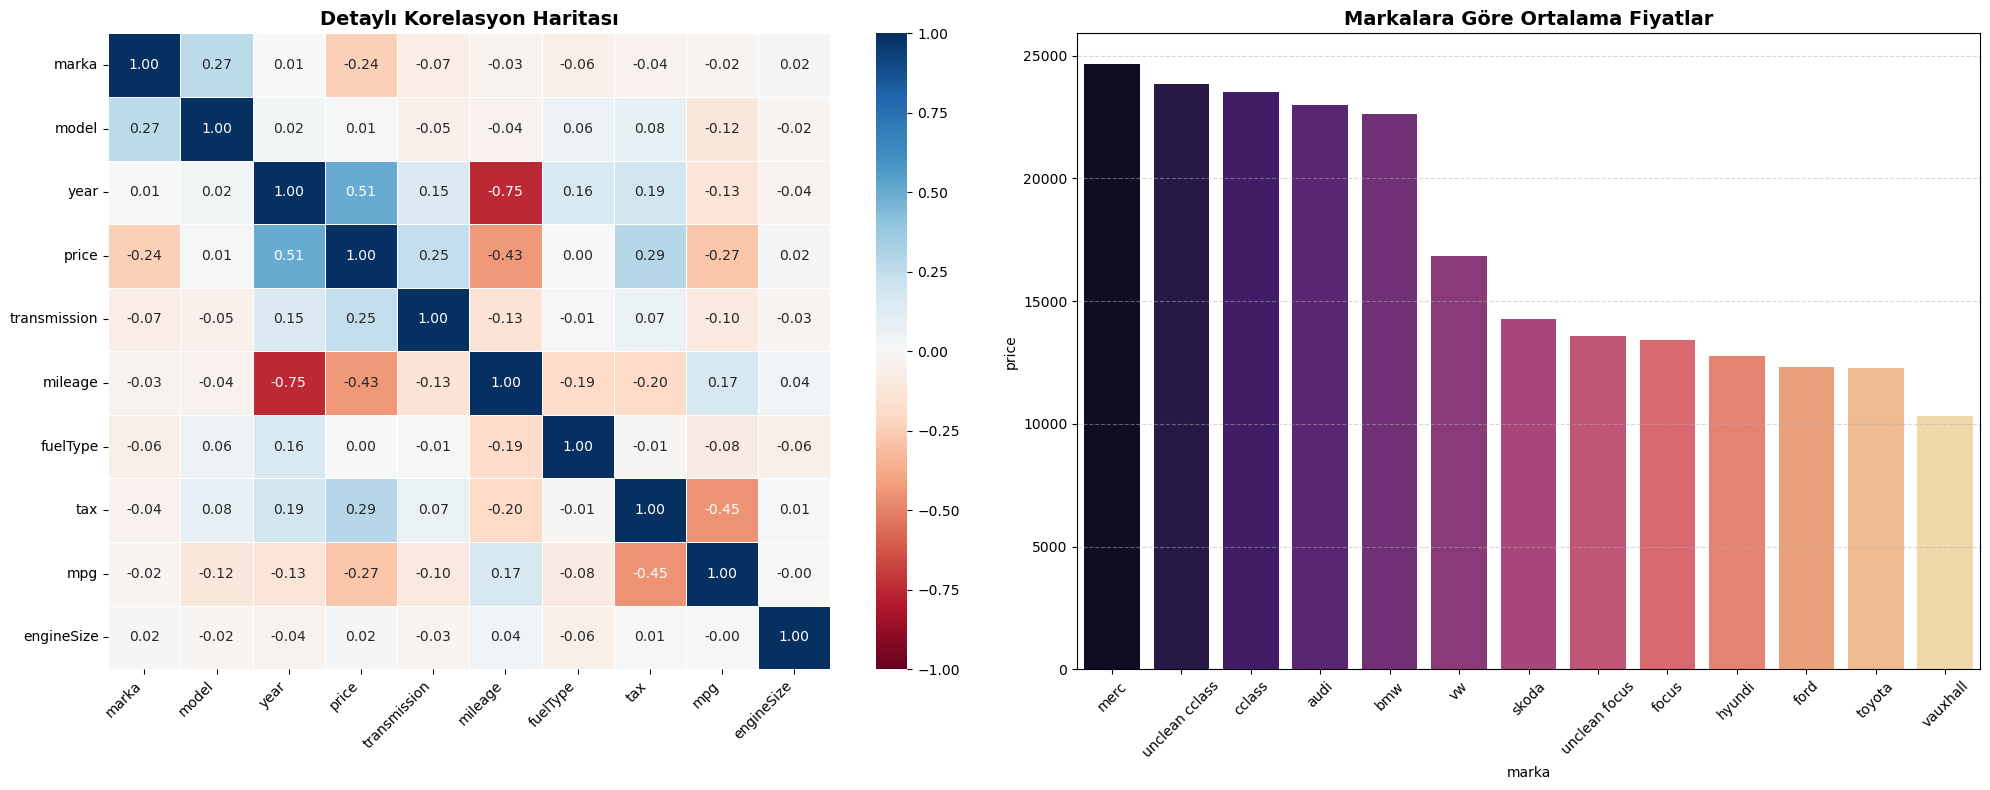

In [14]:
# EDA Görselleştirme
df_viz = pd.read_csv('ekip_odevi_temizlenmis_veri.csv')
df_corr = df_viz.copy()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(20, 8))

# Grafik 1: Korelasyon
plt.subplot(1, 2, 1)
sns.heatmap(df_corr.corr(), annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Detaylı Korelasyon Haritası', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Grafik 2: Marka Fiyat
plt.subplot(1, 2, 2)
avg_price = df_viz.groupby('marka')['price'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='marka', y='price', data=avg_price, palette='magma')
plt.title('Markalara Göre Ortalama Fiyatlar', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# BÖLÜM 2: SENARYO ANALİZİ (Deneysel Tasarım)
### Amaç: Hibrit Model Hangi Veri Yapısında En İyi Çalışıyor?
Voting Regressor modeli aşağıdaki 4 senaryoda test edilecektir:
1.  **Voting (Ham Veri):** Sadece standartlaştırılmış veri.
2.  **Voting + PCA:** %95 Varyans korunarak boyut indirgeme.
3.  **Voting + Kümeleme:** K-Means segment bilgisi eklenmiş veri.
4.  **Voting + Hibrit:** Hem PCA hem de Kümeleme içeren veri.

Her senaryo için **R2, MAE, MSE, RMSE, MAPE** metrikleri hesaplanacaktır. veri.

In [15]:
# Sonuçları saklayacak liste
senaryo_sonuclari = []

# --- 1. VOTING MODEL FONKSİYONU ---
def get_voting_model():
    # Model 1: Ridge (Vize Modeli - alpha ayarlı)
    reg1 = Ridge(alpha=1.0)
    
    # Model 2: SVR (Vize Modeli - Biraz daha güçlendirdik C=1000)
    # C değerini artırmak, SVR'ın hatalara karşı daha hassas olmasını sağlar (Başarıyı artırabilir)
    reg2 = SVR(kernel='rbf', C=1000) 
    
    # Model 3: Extra Trees (Gelişmiş Model - n_estimators artırıldı)
    reg3 = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    
    # Voting: ExtraTrees'e 2 kat ağırlık veriyoruz çünkü en güçlüsü o.
    # weights=[1, 1, 2] -> Ridge(1), SVR(1), ExtraTrees(2)
    return VotingRegressor(
        estimators=[('ridge', reg1), ('svr', reg2), ('extra_trees', reg3)],
        weights=[1, 1, 2] 
    )

# --- 2. METRİK HESAPLAYICI FONKSİYON ---
def hesapla_ve_ekle(senaryo_adi, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    senaryo_sonuclari.append({
        'Senaryo': senaryo_adi,
        'R2 Score': r2,
        'MAE (TL)': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'MSE': mse
    })
    print(f"-> {senaryo_adi} Tamamlandı. (R2: {r2:.4f})")

print("Orijinal Modeller Hazırlandı (Ağırlıklandırılmış).")

Orijinal Modeller Hazırlandı (Ağırlıklandırılmış).


### Senaryo 1: Voting (Ham Veri)
Referans noktamızdır. Ridge, SVR ve ExtraTrees modelleri standart veri üzerinde eğitilir.

>>> Senaryo 1: Voting (Ham) Çalışıyor...
-> 1. Voting (Ham) Tamamlandı. (R2: 0.8894)


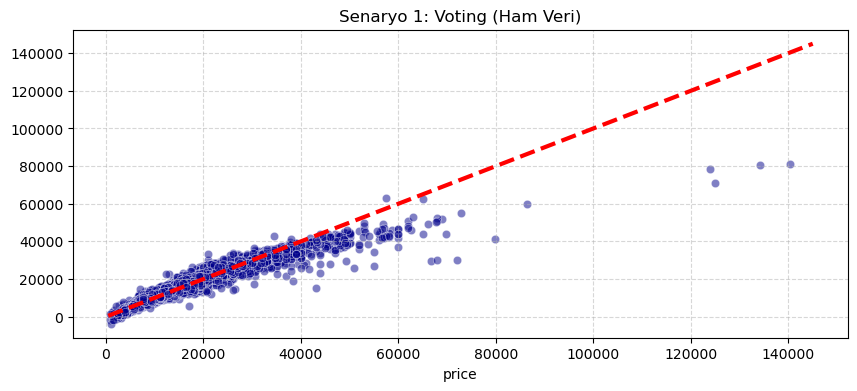

In [16]:
print(">>> Senaryo 1: Voting (Ham) Çalışıyor...")

model_v1 = get_voting_model()
model_v1.fit(X_train_scaled, y_train)
y_pred_v1 = model_v1.predict(X_test_scaled)

hesapla_ve_ekle('1. Voting (Ham)', y_test, y_pred_v1)

plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred_v1, alpha=0.5, color='darkblue', edgecolor='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.title('Senaryo 1: Voting (Ham Veri)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Senaryo 2: Voting + PCA
Veri setindeki varyansın **%95'i** korunarak boyut indirgeme uygulanır. Özellikle Ridge ve SVR modellerinin PCA ile performans artışı göstermesi beklenebilir.

>>> Senaryo 2: PCA Çalışıyor...
-> 2. PCA Tamamlandı. (R2: 0.8525)


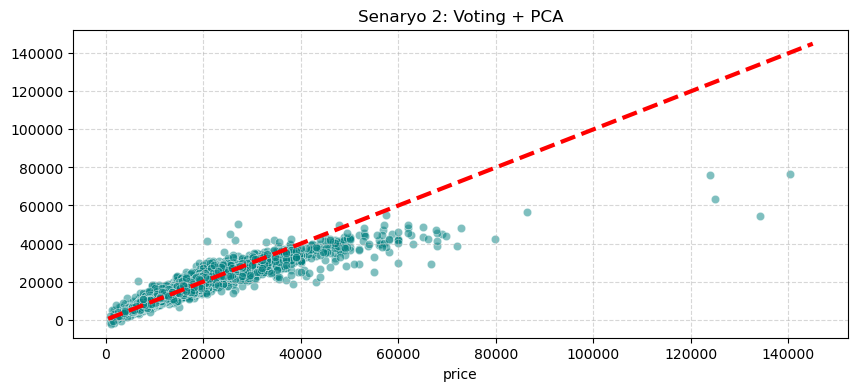

In [17]:
print(">>> Senaryo 2: PCA Çalışıyor...")

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_v2 = get_voting_model()
model_v2.fit(X_train_pca, y_train)
y_pred_v2 = model_v2.predict(X_test_pca)

hesapla_ve_ekle('2. PCA', y_test, y_pred_v2)

plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred_v2, alpha=0.5, color='teal', edgecolor='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.title('Senaryo 2: Voting + PCA')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Senaryo 3: Voting + Kümeleme
K-Means (k=3) ile araçlar segmentlere ayrılır ve bu bilgi modele eklenir. ExtraTrees bileşeni bu bilgiyi kullanarak dallanma kararlarını iyileştirebilir.

>>> Senaryo 3: Kümeleme Çalışıyor...
-> 3. Kümeleme Tamamlandı. (R2: 0.8878)


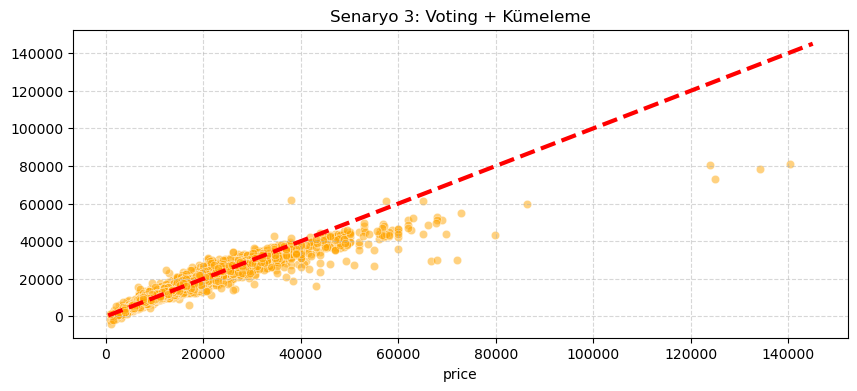

In [18]:
print(">>> Senaryo 3: Kümeleme Çalışıyor...")

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

X_train_cluster = np.hstack([X_train_scaled, train_clusters.reshape(-1, 1)])
X_test_cluster = np.hstack([X_test_scaled, test_clusters.reshape(-1, 1)])

model_v3 = get_voting_model()
model_v3.fit(X_train_cluster, y_train)
y_pred_v3 = model_v3.predict(X_test_cluster)

hesapla_ve_ekle('3. Kümeleme', y_test, y_pred_v3)

plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred_v3, alpha=0.5, color='orange', edgecolor='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.title('Senaryo 3: Voting + Kümeleme')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Senaryo 4: Voting + Hibrit (PCA + Kümeleme)
PCA ve Kümeleme tekniklerinin birlikte kullanıldığı en karmaşık veri yapısıdır.

>>> Senaryo 4: Hibrit Çalışıyor...
-> 4. Hibrit Tamamlandı. (R2: 0.8533)


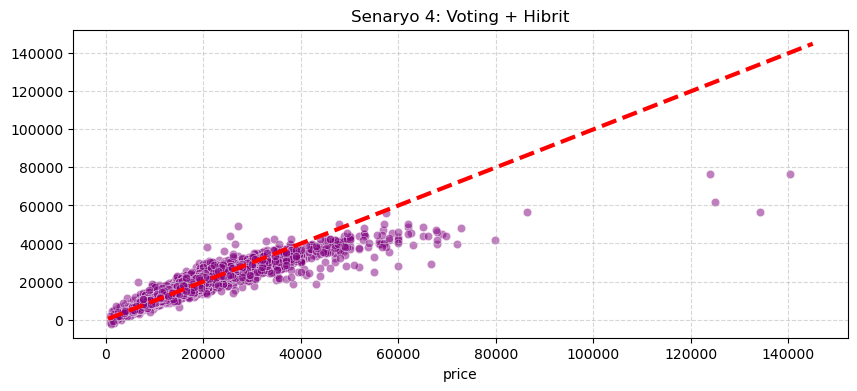

In [19]:
print(">>> Senaryo 4: Hibrit Çalışıyor...")

X_train_hybrid = np.hstack([X_train_pca, train_clusters.reshape(-1, 1)])
X_test_hybrid = np.hstack([X_test_pca, test_clusters.reshape(-1, 1)])

model_v4 = get_voting_model()
model_v4.fit(X_train_hybrid, y_train)
y_pred_v4 = model_v4.predict(X_test_hybrid)

hesapla_ve_ekle('4. Hibrit', y_test, y_pred_v4)

plt.figure(figsize=(10, 4))
sns.scatterplot(x=y_test, y=y_pred_v4, alpha=0.5, color='purple', edgecolor='w')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.title('Senaryo 4: Voting + Hibrit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Sonuçların Karşılaştırılması (Final Tablo ve Grafik)
Aşağıdaki tabloda, Voting Regressor modelinin tüm senaryolardaki detaylı performansı sunulmuştur.


>>> VOTING REGRESSOR: SENARYO KARŞILAŞTIRMA TABLOSU <<<
           Senaryo  R2 Score     MAE (TL)         RMSE   MAPE (%)  \
0  1. Voting (Ham)  0.889386  1821.126430  3263.022684  11.395430   
1           2. PCA  0.852506  2114.723765  3767.918931  13.066789   
2      3. Kümeleme  0.887836  1836.337477  3285.801791  11.435986   
3        4. Hibrit  0.853318  2111.205195  3757.543256  13.032840   

            MSE  
0  1.064732e+07  
1  1.419721e+07  
2  1.079649e+07  
3  1.411913e+07  


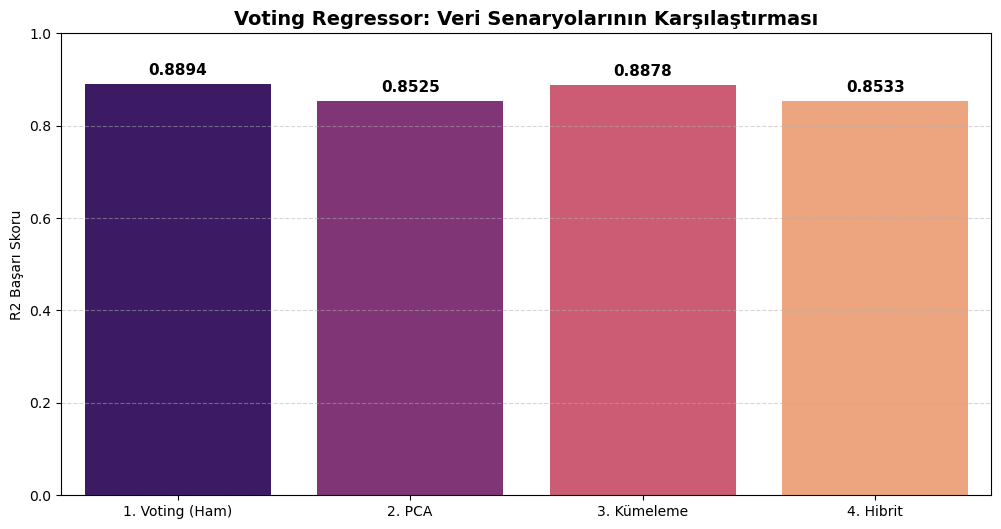

In [20]:
# 1. TABLO
df_senaryo_voting = pd.DataFrame(senaryo_sonuclari)

# Sütun sırasını düzenle
cols = ['Senaryo', 'R2 Score', 'MAE (TL)', 'RMSE', 'MAPE (%)', 'MSE']
df_senaryo_voting = df_senaryo_voting[cols]

print("\n" + "="*60)
print(">>> VOTING REGRESSOR: SENARYO KARŞILAŞTIRMA TABLOSU <<<")
print("="*60)
print(df_senaryo_voting)
print("="*60)

# 2. GRAFİK (R2 Skoru)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Senaryo', y='R2 Score', data=df_senaryo_voting, palette='magma')

plt.title('Voting Regressor: Veri Senaryolarının Karşılaştırması', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('R2 Başarı Skoru')
plt.xlabel('')

# Değerleri yaz
for i, v in enumerate(df_senaryo_voting['R2 Score']):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()